# 데이터 인코딩 방식과 피처 맵 (Data Encoding Schemes & Feature Maps)

양자 컴퓨터는 고전적인 숫자 데이터(0, 1, 3.14 같은 값)를 직접 이해하지 못합니다. 고전 데이터를 양자 상태로 변환하는 과정이 필요하며, 이 과정을 **데이터 인코딩**이라 합니다. **피처 맵(feature map)** 은 데이터 인코딩에 얽힘 층과 반복 구조를 추가하여, 데이터를 고차원 양자 힐베르트 공간으로 매핑하는 양자 회로입니다. 즉, 모든 피처 맵은 인코딩을 포함하지만, 모든 인코딩이 피처 맵인 것은 아닙니다.

이 노트북에서 다루는 내용:
- **데이터 인코딩 방식:** 기저(Basis), 진폭(Amplitude), 각도(Angle), 위상(Phase), 밀집 각도(Dense Angle)
- **피처 맵:** Z 피처 맵, ZZ 피처 맵, Pauli 피처 맵
- **매개변수화 회로:** `efficient_su2()`와 `n_local()`

### 사전 준비
이 노트북을 실행하는 경우, 환경에 다음 라이브러리가 설치되어 있어야 합니다. Google Colab에서 실행하는 경우에도 아래 라이브러리를 최신 버젼으로 설치해야 합니다.

`qiskit, qiskit-aer, matplotlib, pylatexenc`

In [1]:
#!pip install qiskit qiskit-aer matplotlib pylatexenc

## Part 1: 데이터 인코딩 (Data Encoding)

데이터 인코딩은 고전 데이터를 양자 상태로 변환하는 **가장 기본적인 과정**입니다. 학습에 사용할 고전 데이터(숫자, 벡터 등)를 양자 컴퓨터가 처리할 수 있는 양자 상태로 "번역"하는 것이 목적입니다.


### 1. 기저 인코딩 (Basis Encoding)

#### 직관적 이해

기저 인코딩은 가장 단순한 인코딩 방식입니다. **숫자를 이진수로 바꾸고, 각 비트를 큐비트에 그대로 대응시키는 것**입니다.

#### 작동 원리

모든 특성(feature)이 4비트로 저장된다고 가정합니다 (0~15 범위의 값 표현 가능):

| 특성값 | 이진수 표현 |
|:---:|:---:|
| 5 | 0101 |
| 7 | 0111 |
| 1 | 0001 |

이 비트 문자열들은 각각 4개의 큐비트 세트에 할당되므로, 전체 12큐비트 기저 상태는 $|0101\; 0111\; 0001\rangle$이 됩니다.

- 처음 4개의 큐비트 → 첫 번째 특성 (5)
- 다음 4개의 큐비트 → 두 번째 특성 (7)
- 마지막 4개의 큐비트 → 세 번째 특성 (1)


원본 데이터: [5, 7, 1]
비트 수/특성: 4
필요 큐비트 수: 12개

  5 -> 0101 -> [0, 1, 0, 1]
  7 -> 0111 -> [0, 1, 1, 1]
  1 -> 0001 -> [0, 0, 0, 1]

회로:


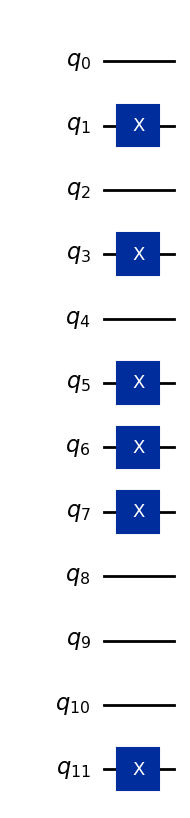


Bloch 구면 시각화:
  각 큐비트는 |0> (북극) 또는 |1> (남극)에 위치


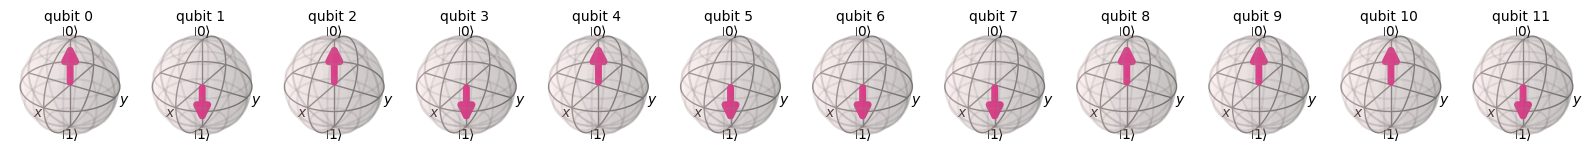

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# === 기저 인코딩 예제: 데이터 벡터 (5, 7, 1) ===
data = [5, 7, 1]
bits_per_value = 4
print(f"원본 데이터: {data}")
print(f"비트 수/특성: {bits_per_value}")
print(f"필요 큐비트 수: {len(data) * bits_per_value}개\n")

# 각 값을 4비트 이진수로 변환
all_bits = []
for val in data:
    bits = [int(b) for b in format(val, f"0{bits_per_value}b")]
    print(f"  {val} -> {format(val, f'0{bits_per_value}b')} -> {bits}")
    all_bits.extend(bits)

# 12큐비트 양자 회로: 비트가 1인 위치에 X 게이트 적용
qc = QuantumCircuit(len(all_bits))
for idx, bit in enumerate(all_bits):
    if bit == 1:
        qc.x(idx)

print(f"\n회로:")
display(qc.draw("mpl"))

# Bloch 구면 시각화
state = Statevector.from_instruction(qc)
print("\nBloch 구면 시각화:")
print("  각 큐비트는 |0> (북극) 또는 |1> (남극)에 위치")
display(plot_bloch_multivector(state))

### 2. 진폭 인코딩 (Amplitude Encoding)

#### 직관적 이해

진폭 인코딩은 데이터를 양자 상태의 **진폭(amplitude)**에 저장합니다. 양자 상태는 여러 기저 상태의 "중첩"으로 표현되는데, 각 기저 상태 앞에 붙는 계수(진폭)에 데이터 값을 담는 것입니다.

#### 작동 원리

예제 데이터 벡터 $\vec{x}^{(1)} = (5, 7, 1)$을 인코딩해 봅시다. 기저 인코딩과 같은 데이터를 사용합니다.

**단계 1: 정규화** — 양자 상태의 확률 총합은 반드시 1이어야 합니다. 따라서 벡터를 정규화합니다:
$$
\|\vec{x}\|^2 = 5^2 + 7^2 + 1^2 = 25 + 49 + 1 = 75 \quad \Rightarrow \quad \alpha = \sqrt{75}
$$

**단계 2: 큐비트 수 결정** — 3개의 특성을 저장하려면 $2^n \geq 3$을 만족하는 최소 $n$이 필요합니다. $2^2 = 4 \geq 3$이므로 **2개의 큐비트**로 충분합니다. 남는 한 칸($|11\rangle$)은 0으로 채웁니다.

**단계 3: 양자 상태 구성**
$$
|\psi(\vec{x}^{(1)})\rangle = \frac{5}{\sqrt{75}}|00\rangle + \frac{7}{\sqrt{75}}|01\rangle + \frac{1}{\sqrt{75}}|10\rangle + \frac{0}{\sqrt{75}}|11\rangle
$$

| 기저 상태 | 진폭 | 의미 |
|:---:|:---:|:---:|
| 00 | $5/\sqrt{75} \approx 0.577$ | 첫 번째 특성 (5) |
| 01 | $7/\sqrt{75} \approx 0.808$ | 두 번째 특성 (7) |
| 10 | $1/\sqrt{75} \approx 0.115$ | 세 번째 특성 (1) |
| 11 | $0$ | 패딩 (사용 안 함) |

Qiskit의 `initialize` 메서드를 사용하면 진폭 인코딩을 쉽게 구현할 수 있습니다:

원본 데이터: [5, 7, 1]
정규화 상수: sqrt(75) = 8.6603
필요 큐비트 수: 2개 (2^2 = 4 >= 3)

  |00> : 5/8.66 = 0.5774  (특성값 5)
  |01> : 7/8.66 = 0.8083  (특성값 7)
  |10> : 1/8.66 = 0.1155  (특성값 1)
  |11> : 0/8.66 = 0.0000  (패딩)

회로:


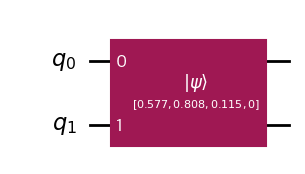


Bloch 구면 시각화:
  4개 진폭 중 3개가 nonzero -> 일반적으로 얽힌 상태
  각 큐비트의 축소 밀도 행렬(partial trace)을 표시


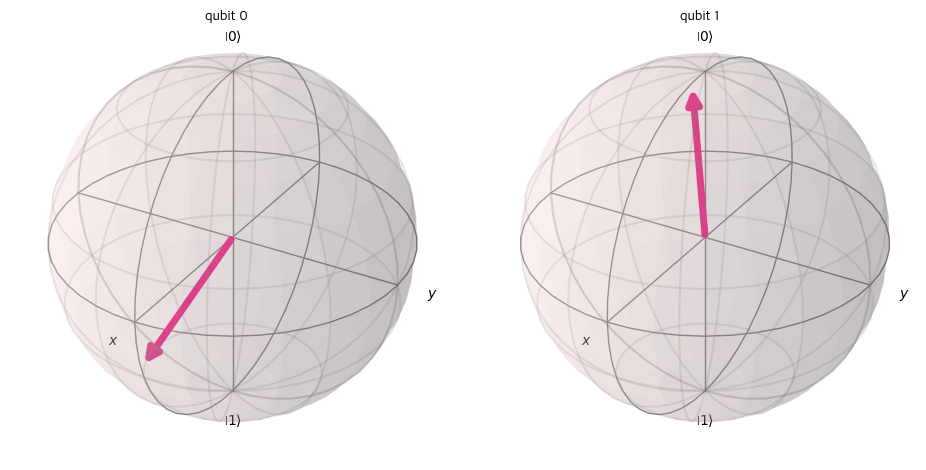

In [25]:
import math
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# === 진폭 인코딩 예제: 같은 데이터 (5, 7, 1) ===
data = [5, 7, 1]
norm = math.sqrt(sum(v**2 for v in data))
n_qubits = math.ceil(math.log2(len(data)))
print(f"원본 데이터: {data}")
print(f"정규화 상수: sqrt({sum(v**2 for v in data)}) = {norm:.4f}")
print(f"필요 큐비트 수: {n_qubits}개 (2^{n_qubits} = {2**n_qubits} >= {len(data)})\n")

# 정규화 + 패딩 (2^n 길이에 맞춤)
padded = data + [0] * (2**n_qubits - len(data))
desired_state = [v / norm for v in padded]
for i, (val, amp) in enumerate(zip(padded, desired_state)):
    label = f"특성값 {val}" if i < len(data) else "패딩"
    print(f"  |{format(i, f'0{n_qubits}b')}> : {val}/{norm:.2f} = {amp:.4f}  ({label})")

# 회로 생성
qc = QuantumCircuit(n_qubits)
qc.initialize(desired_state, list(range(n_qubits)))

print(f"\n회로:")
display(qc.draw(output="mpl"))

# Bloch 구면 시각화
state = Statevector.from_instruction(qc)
print("\nBloch 구면 시각화:")
print("  4개 진폭 중 3개가 nonzero -> 일반적으로 얽힌 상태")
print("  각 큐비트의 축소 밀도 행렬(partial trace)을 표시")
display(plot_bloch_multivector(state))

### 3. 각도 인코딩 (Angle Encoding)

#### 직관적 이해

각도 인코딩은 데이터 값을 큐비트의 **회전 각도**로 변환합니다. 큐비트 하나가 데이터 특성 하나를 담당하고, 그 특성값만큼 큐비트를 회전시킵니다.

#### 핵심 특징

- 각 특성값은 해당하는 큐비트에 매핑: $x_k \rightarrow Q_k$
- 큐비트 간 얽힘 없이 각각 독립적 (곱 상태)
- 회로 깊이가 1로 일정 (회전 게이트 하나만 적용)
- $N$개의 특성에 $N$개의 큐비트 필요

#### 스케일링이 필요한 이유

$R_Y$ (Y축 회전) 게이트는 $2\pi$ 주기이므로, 원본 데이터를 그대로 넣으면 **서로 다른 값이 같은 회전 결과를 만들 수 있습니다** (예: $R_Y(1) = R_Y(1 + 2\pi)$). 이를 방지하기 위해 데이터를 특정 범위로 스케일링하는 것이 표준입니다:

| 스케일링 범위 | 수식 | Bloch 구면 활용 |
|:---|:---|:---|
| $[0, \pi]$ (가장 일반적) | $\displaystyle x_k^{\text{sc}} = \frac{x_k - x_{\min}}{x_{\max} - x_{\min}} \cdot \pi$ | 북극($|0\rangle$) ~ 남극($|1\rangle$) |
| $[0, 2\pi]$ | $\cdots \times 2\pi$ | 전체 Y 대원 |
| $[-\pi, \pi]$ | $\cdots \times 2\pi - \pi$ | 남극 중심 대칭 |

이 노트북에서는 가장 일반적인 **$[0, \pi]$** 스케일링을 사용합니다. 최솟값이 $|0\rangle$ (북극), 최댓값이 $|1\rangle$ (남극)에 매핑됩니다.

스케일링된 $N$개의 특성을 인코딩한 양자 상태:
$$
|\vec{x}^{(j)}\rangle = \bigotimes^N_{k=1} R_Y(x^{(j)}_{\text{sc},k})|0\rangle = \bigotimes^N_{k=1} \left[\cos\!\left(\frac{x^{(j)}_{\text{sc},k}}{2}\right)|0\rangle + \sin\!\left(\frac{x^{(j)}_{\text{sc},k}}{2}\right)|1\rangle\right]
$$

다음 코드는 진폭 인코딩에서 사용했던 같은 데이터 $\vec{x} = (5, 7, 1)$을 각도 인코딩합니다. 기저/진폭 인코딩과 같은 데이터를 사용합니다. **스케일링 과정**을 포함하여 실전에서의 사용법을 보여줍니다:

원본 데이터: [5 7 1]
필요 큐비트 수: 3개

스케일링 [1 ~ 7] -> [0, pi]:
  x_0 = 5 -> 2.0944 rad (0.67pi)
  x_1 = 7 -> 3.1416 rad (1.00pi)
  x_2 = 1 -> 0.0000 rad (0.00pi)

회로:


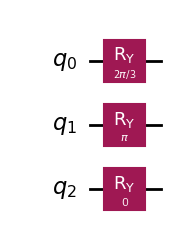


Bloch 구면 시각화:
  Q0: x=5 -> theta=2pi/3  -> 적도~남극 사이
  Q1: x=7 -> theta=pi     -> |1> (남극, 최댓값)
  Q2: x=1 -> theta=0      -> |0> (북극, 최솟값)


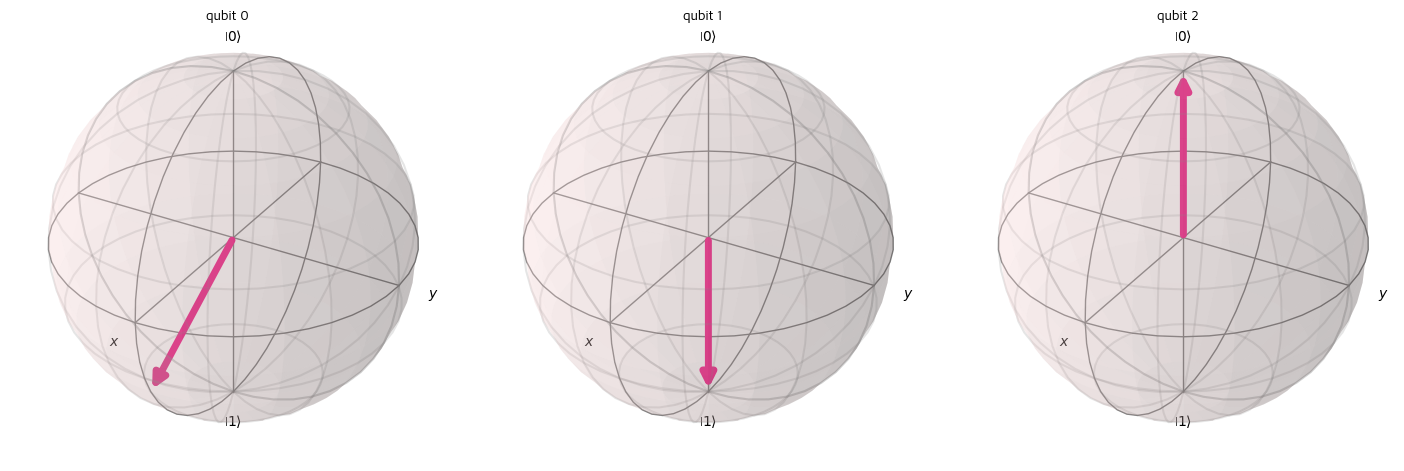

In [26]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi

# === 기저/진폭 인코딩과 같은 데이터를 각도 인코딩으로 비교 ===
data = np.array([5, 7, 1])
print(f"원본 데이터: {data}")
print(f"필요 큐비트 수: {len(data)}개\n")

# 스케일링: [0, pi] 범위로 변환
x_min, x_max = data.min(), data.max()
scaled = (data - x_min) / (x_max - x_min) * pi
print(f"스케일링 [{x_min} ~ {x_max}] -> [0, pi]:")
for i, (orig, sc) in enumerate(zip(data, scaled)):
    print(f"  x_{i} = {orig} -> {sc:.4f} rad ({sc/pi:.2f}pi)")

# 3큐비트 회로: 각 큐비트에 R_Y(scaled_x) 적용
qc = QuantumCircuit(3)
for i, angle in enumerate(scaled):
    qc.ry(angle, i)

print(f"\n회로:")
display(qc.draw("mpl"))

# Bloch 구면 시각화
state = Statevector.from_instruction(qc)
print("\nBloch 구면 시각화:")
print("  Q0: x=5 -> theta=2pi/3  -> 적도~남극 사이")
print("  Q1: x=7 -> theta=pi     -> |1> (남극, 최댓값)")
print("  Q2: x=1 -> theta=0      -> |0> (북극, 최솟값)")
display(plot_bloch_multivector(state))

### 4. 위상 인코딩 (Phase Encoding)

#### 직관적 이해

위상 인코딩은 데이터 값을 큐비트의 **위상(phase)** 에 저장합니다. 각도 인코딩이 Bloch 구면의 "위도"를 바꾸는 것이라면, 위상 인코딩은 "경도"를 바꾸는 것입니다.

#### 작동 원리

**단계 1:** 먼저 하다마드(Hadamard) 게이트로 큐비트를 $|+\rangle$ 상태로 만듭니다:
$$
H|0\rangle = |+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)
$$

**단계 2:** 위상 게이트 $P(\phi)$를 적용하여 $|1\rangle$ 성분에 위상 $e^{i\phi}$를 부여합니다:
$$
P(\phi)|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + e^{i\phi}|1\rangle)
$$

$N$개 특성의 위상 인코딩된 다중 큐비트 상태 (스케일링된 값 $x_{\text{sc},k}^{(j)}$를 대입):
$$
|\vec{x}^{(j)}\rangle = \frac{1}{\sqrt{2^N}} \bigotimes_{k=1}^{N}\big(|0\rangle + e^{ix_{\text{sc},k}^{(j)}}|1\rangle\big)
$$

여기서 $x_{\text{sc},k}^{(j)}$는 원본 데이터를 $[0, 2\pi)$ 등의 범위로 스케일링한 값입니다. 하다마드 층을 포함하여 회로 깊이가 2이므로, 매우 효율적인 인코딩입니다.

> **참고 (Optional):** $[0, 2\pi)$ 스케일링에서는 최솟값(→ 0)과 최댓값(→ $2\pi$)이 Bloch 구면 위 같은 지점(+X축)에 매핑됩니다. 이 경우 두 극단값이 구별 불가능해지므로, 데이터 범위에 따라 $[0, 2\pi - \epsilon]$이나 다른 스케일링을 고려할 수 있습니다. 이 내용은 시험 범위 밖입니다.


원본 데이터: [5 7 1]
필요 큐비트 수: 3개

스케일링 [1 ~ 7] -> [0, 2pi]:
  x_0 = 5 -> 4.1888 rad (1.33pi)
  x_1 = 7 -> 6.2832 rad (2.00pi)
  x_2 = 1 -> 0.0000 rad (0.00pi)

회로:


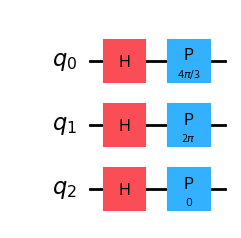


Bloch 구면 시각화:
  모든 큐비트가 적도 위에 위치하며, 경도(위상)만 다름
  Q0: x=5 -> 4pi/3 방향
  Q1: x=7 -> 2pi 방향 (= 0, +X축)
  Q2: x=1 -> 0 방향 (+X축)


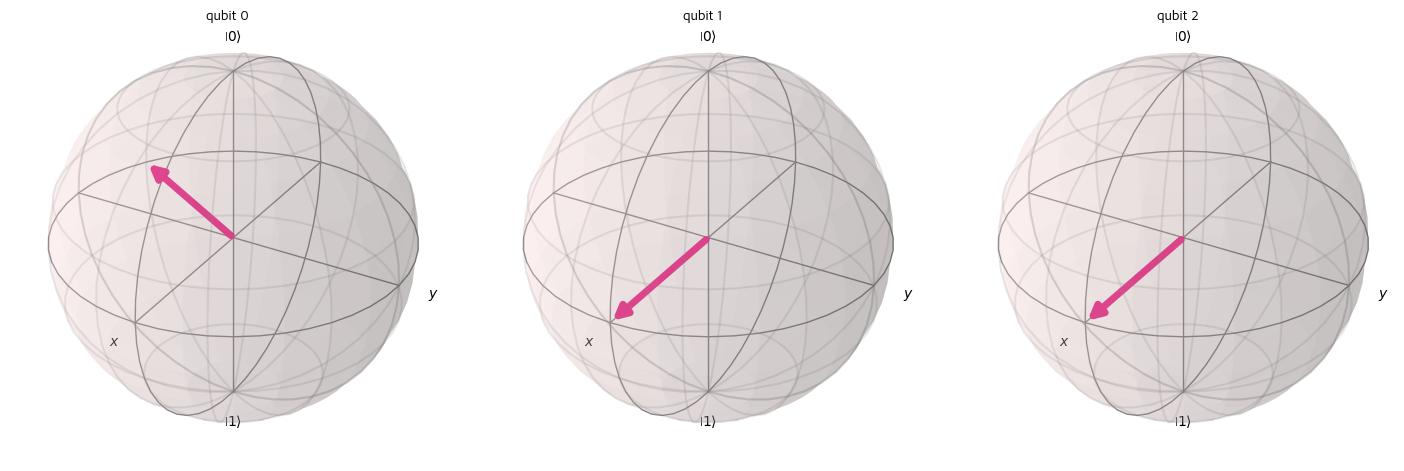

In [28]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi
import numpy as np

# === 위상 인코딩 예제: 같은 데이터 (5, 7, 1) ===
data = np.array([5, 7, 1])


# 스케일링: [0, 2pi] 범위로 변환 (위상은 [0, 2pi) 전체 활용)
x_min, x_max = data.min(), data.max()
scaled = (data - x_min) / (x_max - x_min) * 2 * pi
print(f"원본 데이터: {data}")
print(f"필요 큐비트 수: {len(data)}개\n")
print(f"스케일링 [{x_min} ~ {x_max}] -> [0, 2pi]:")
for i, (orig, sc) in enumerate(zip(data, scaled)):
    print(f"  x_{i} = {orig} -> {sc:.4f} rad ({sc/pi:.2f}pi)")

# 3큐비트 회로: H + P(scaled_x)
qc = QuantumCircuit(len(data))
for i, phase in enumerate(scaled):
    qc.h(i)
    qc.p(phase, i)

print(f"\n회로:")
display(qc.draw("mpl"))

# Bloch 구면 시각화
state = Statevector.from_instruction(qc)
print("\nBloch 구면 시각화:")
print("  모든 큐비트가 적도 위에 위치하며, 경도(위상)만 다름")
print("  Q0: x=5 -> 4pi/3 방향")
print("  Q1: x=7 -> 2pi 방향 (= 0, +X축)")
print("  Q2: x=1 -> 0 방향 (+X축)")
display(plot_bloch_multivector(state))

### 5. (Optional) 밀집 각도 인코딩 (Dense Angle Encoding)

> **이 섹션은 Qiskit v2.X 자격증 시험 범위에 포함되지 않습니다.** 양자 인코딩의 이해를 넓히고 싶은 분만 참고하세요.

#### 직관적 이해

밀집 각도 인코딩(DAE)은 각도 인코딩과 위상 인코딩을 **결합**한 방식입니다. 하나의 큐비트에 **두 개의 특성값**을 동시에 저장할 수 있어, 필요한 큐비트 수가 절반으로 줄어듭니다.

#### 작동 원리

- **$R_Y(\theta)$**: Y축 회전으로 첫 번째 특성값 인코딩 (Bloch 구면의 "위도" 변경)
- **$R_Z(\phi)$**: Z축 회전으로 두 번째 특성값 인코딩 (Bloch 구면의 "경도" 변경)

$N$개 특성의 밀집 각도 인코딩 (0-based 인덱싱, $k = 0, 1, \ldots, N/2 - 1$):
$$
|\vec{x}\rangle = \bigotimes_{k=0}^{N/2-1} R_Z(x_{2k+1})\,R_Y(x_{2k})\,|0\rangle = \bigotimes_{k=0}^{N/2-1} \left[e^{-ix_{2k+1}/2}\cos\!\left(\frac{x_{2k}}{2}\right)|0\rangle + e^{ix_{2k+1}/2}\sin\!\left(\frac{x_{2k}}{2}\right)|1\rangle\right]
$$

> **$R_Z$ vs $P$ 게이트:** 위 수식은 $R_Z(\phi) = e^{-i\phi Z/2}$를 사용합니다. 문헌에 따라 $P(\phi)$ 게이트($|1\rangle$에만 $e^{i\phi}$ 적용)를 쓰는 경우도 있는데, 둘은 global phase가 다릅니다. 단일 큐비트 측정에서는 구별되지 않지만, controlled 연산과 결합될 때는 차이가 날 수 있습니다.

아래 코드는 앞선 예제와 같은 데이터 $(5, 7, 1)$을 패딩 후 $(5, 7, 1, 0)$으로 만들어 DAE로 인코딩합니다:

원본 데이터: [5, 7, 1]
패딩 후: [5, 7, 1, 0] (짝수개로 맞춤)
필요 큐비트 수: 2개 (각도 인코딩 3개의 절반 + 올림)

큐비트별 인코딩:
  Q0: R_Y(x_0=5 -> 2.2440) + R_Z(x_1=7 -> 6.2832)
  Q1: R_Y(x_2=1 -> 0.4488) + R_Z(x_3=0 -> 0.0000)

회로:


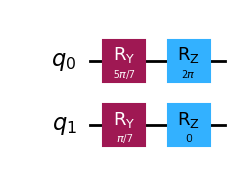


Bloch 구면 시각화:
  Q0: R_Y(5) + R_Z(7) -> 위도와 경도 모두 변화
  Q1: R_Y(1) + R_Z(0) -> 약간 회전 + 회전 없음


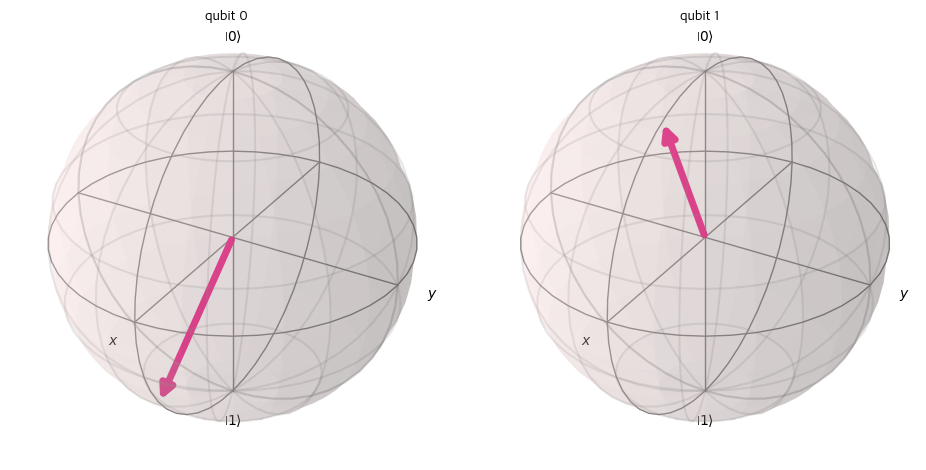

In [29]:

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi
import numpy as np

# === 밀집 각도 인코딩 예제: 같은 데이터 (5, 7, 1) ===
# 홀수개이므로 패딩 추가 -> (5, 7, 1, 0)
data_raw = [5, 7, 1]
data = data_raw + [0]  # 패딩
n_qubits = len(data) // 2
print(f"원본 데이터: {data_raw}")
print(f"패딩 후: {data} (짝수개로 맞춤)")
print(f"필요 큐비트 수: {n_qubits}개 (각도 인코딩 {len(data_raw)}개의 절반 + 올림)\n")

# 스케일링: 패딩 포함 전체 데이터 기준
# R_Y용 [0, pi], R_Z용 [0, 2pi]
arr = np.array(data, dtype=float)
x_min, x_max = arr.min(), arr.max()  # 0~7 (패딩 포함)
scaled_y = (arr - x_min) / (x_max - x_min) * pi
scaled_z = (arr - x_min) / (x_max - x_min) * 2 * pi

print("큐비트별 인코딩:")
qc = QuantumCircuit(n_qubits)
for k in range(n_qubits):
    theta = scaled_y[2*k]
    phi   = scaled_z[2*k + 1]
    qc.ry(theta, k)
    qc.rz(phi, k)
    print(f"  Q{k}: R_Y(x_{2*k}={data[2*k]} -> {theta:.4f}) + R_Z(x_{2*k+1}={data[2*k+1]} -> {phi:.4f})")

print(f"\n회로:")
display(qc.draw("mpl"))

# Bloch 구면 시각화
state = Statevector.from_instruction(qc)
print("\nBloch 구면 시각화:")
print("  Q0: R_Y(5) + R_Z(7) -> 위도와 경도 모두 변화")
print("  Q1: R_Y(1) + R_Z(0) -> 약간 회전 + 회전 없음")
display(plot_bloch_multivector(state))


## Part 2: 피처 맵 (Feature Map)

피처 맵은 데이터 인코딩을 **포함** 하지만, 목적이 한 단계 더 나아갑니다. 단순히 데이터를 양자 상태로 넣는 것을 넘어서, 데이터를 **고차원 양자 힐베르트 공간(Hilbert space)** 으로 매핑하여 데이터 간의 구조적 관계를 드러내는 것이 목표입니다.

피처 맵 내부에는 데이터 인코딩이 포함되어 있습니다 (하다마드 + 위상 게이트 = 위상 인코딩의 반복). 다만 피처 맵은 여기에 **반복(reps)** 과 **얽힘 층(entanglement)** 을 추가하여 더 풍부하고 비선형적인 특성 공간을 만드는 것이 핵심입니다.

### 6. Z 피처 맵 (Z Feature Map)

#### 직관적 이해

Z 피처 맵(ZFM)은 **Pauli-Z 방향의 위상 진화를 반복 적용**하는 가장 기본적인 피처 맵입니다. 직관적으로는 위상 인코딩을 반복하는 것과 비슷하지만, **현재 Qiskit의 공식 구현은 스케일 계수 $\alpha$** 를 포함한 `z_feature_map()` 함수로 제공됩니다.

#### 작동 원리

현재 Qiskit 기본값은 $\alpha = 2.0$ 이므로, 1회 반복의 Z 피처 맵은

$$
\mathscr{U}^{(1)}_{\text{ZFM}}(\vec{x};\alpha)
=
\left(\bigotimes_{k=1}^N P(\alpha x_k)\right) H^{\otimes N},
\qquad \alpha_{\text{default}} = 2.0
$$

즉, 기본 설정에서는 각 큐비트에 **$P(2x_k)$** 가 적용됩니다.

$r$회 반복하면,

$$
\mathscr{U}^{(r)}_{\text{ZFM}}(\vec{x};\alpha)
=
\prod_{s=1}^{r}
\left[
\left(\bigotimes_{k=1}^N P(\alpha x_k)\right) H^{\otimes N}
\right].
$$

이 피처 맵은 **얽힘이 없어서** 각 큐비트가 독립적으로 진화합니다. 따라서 특성 간 pairwise interaction은 직접 만들지 못하지만, 가장 단순하고 해석하기 쉬운 기준선(baseline) 피처 맵으로 자주 사용됩니다.


x0 = π/2, x1 = π/3


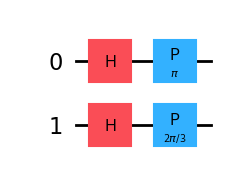

In [30]:
from math import pi
from qiskit.circuit.library import z_feature_map

# 최신 Qiskit 정의에 맞춘 Z 피처 맵 예제
# current default: alpha = 2.0  ->  single-qubit phase term is P(2*x_k)

x0, x1 = pi / 2, pi / 3
zfm = z_feature_map(feature_dimension=2, reps=1, alpha=2.0)

qc = zfm.assign_parameters([x0, x1])

print(f"x0 = π/2, x1 = π/3")
qc.draw("mpl", scale=1)


위의 회로에서 Qiskit default alpha = 2.0 이므로 실제 회로에는 P(π), P(2π/3)가 들어갑니다.

### 7. ZZ 피처 맵 (ZZ Feature Map)

#### 직관적 이해

ZZ 피처 맵(ZZFM)은 Z 피처 맵에 **2큐비트 상호작용 항**을 추가한 것입니다. 이 추가 항 덕분에 특성들 사이의 **pairwise correlation**을 피처 맵 자체에 반영할 수 있습니다.

#### 작동 원리

현재 Qiskit의 `zz_feature_map()`은 $\alpha = 2.0$ 을 기본값으로 쓰며, 1회 반복에서

$$
\phi(x_i) = x_i,
\qquad
\phi(x_i, x_j) = (\pi - x_i)(\pi - x_j)
$$

를 사용합니다. 따라서 한 번의 변환은

$$
\mathscr{U}^{(1)}_{\text{ZZFM}}(\vec{x};\alpha)
=
\left[
\prod_{(i,j)\in E}
CX_{ij}\,P\!\big(\alpha\,\phi(x_i,x_j)\big)\,CX_{ij}
\right]
\left[
\bigotimes_{k=1}^N P(\alpha x_k)
\right]
H^{\otimes N},
\qquad \alpha_{\text{default}} = 2.0
$$

처럼 볼 수 있습니다. 여기서 $E$ 는 entanglement structure(예: `linear`, `circular`, `full`)입니다.
- **linear (선형):** 인접한 큐비트끼리만 연결
- **circular (순환):** 선형 + 마지막과 첫 번째 큐비트도 연결
- **full (완전):** 모든 큐비트 쌍을 연결


In [ ]:
from qiskit.circuit.library import zz_feature_map

# 2차원 특성, 선형 얽힘
# linear: 큐비트 0-1만 연결
feature_dim = 2
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim,
    entanglement="linear",
    reps=1,
    alpha=2.0,
)
print(f"특성 차원: {feature_dim}, 얽힘: linear")
zzfeature_map.draw("mpl", scale=1)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (697662837.py, line 7)

특성 차원: 4, 얽힘: circular


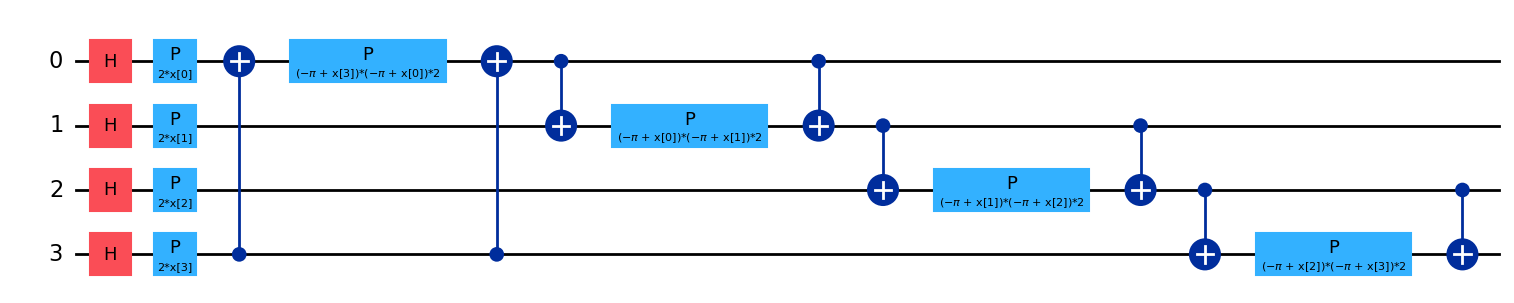

In [9]:
from qiskit.circuit.library import zz_feature_map

# 4차원 특성, 순환 얽힘
# circular: 0-1, 1-2, 2-3, 3-0 연결 (원형)
feature_dim = 4
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="circular", reps=1, alpha=2.0
)
print(f"특성 차원: {feature_dim}, 얽힘: circular")
zzfeature_map.draw("mpl", scale=1)

### 8. Pauli 피처 맵 (Pauli Feature Map)

#### 직관적 이해

Pauli 피처 맵(PFM)은 ZFM과 ZZFM의 **일반화**입니다. 이전까지는 Z 방향 항만 사용했지만, PFM은 **X, Y, Z Pauli 문자열**을 자유롭게 조합해 더 다양한 feature map을 만들 수 있습니다.

현재 Qiskit의 `pauli_feature_map()`은 함수형 API로 제공되며, 기본값 `paulis=None` 은 사실상 `['Z', 'ZZ']` 에 해당합니다. 즉, `z_feature_map()` 과 `zz_feature_map()` 은 더 특화된 convenience wrapper로 볼 수 있습니다.

#### (Optional) 수학적 구조

PFM은 입력 데이터 $x \in \mathbb{R}^n$ 에 대해, 개념적으로

$$
U_{\Phi}(x)
=
\prod_{S\in I}
\exp\!\left(
i \alpha \, \phi_S(x)\prod_{i\in S} P_i
\right)
$$

형태의 Pauli expansion을 사용합니다.

> **참고:** 위 수식은 각 Pauli 항을 **개별적으로 exponentiate** 한 곱(first-order Trotterization)입니다. 만약 서로 commute하지 않는 Pauli 문자열이 포함된 경우(예: `Y`와 `XX`), 이를 하나의 exponential $\exp(i\alpha \sum_S \ldots)$로 합치면 결과가 달라집니다. Qiskit의 실제 구현은 개별 곱 형태를 따릅니다. 여기서
- $P_i \in \{I, X, Y, Z\}$
- $\alpha$: 스케일링 계수 (Qiskit 기본값은 $2.0$)
- $S$: 어떤 큐비트 집합에 해당하는 Pauli 문자열인지 나타내는 index set

기본 데이터 맵은

$$
\phi_S(\vec{x}) = \begin{cases}
  x_i & \text{if } S = \{i\} \\
  \displaystyle\prod_{j\in S}(\pi - x_j) & \text{if } |S| > 1
\end{cases}
$$

입니다.


특성 차원: 3, Pauli 문자열: ['Y', 'XX']


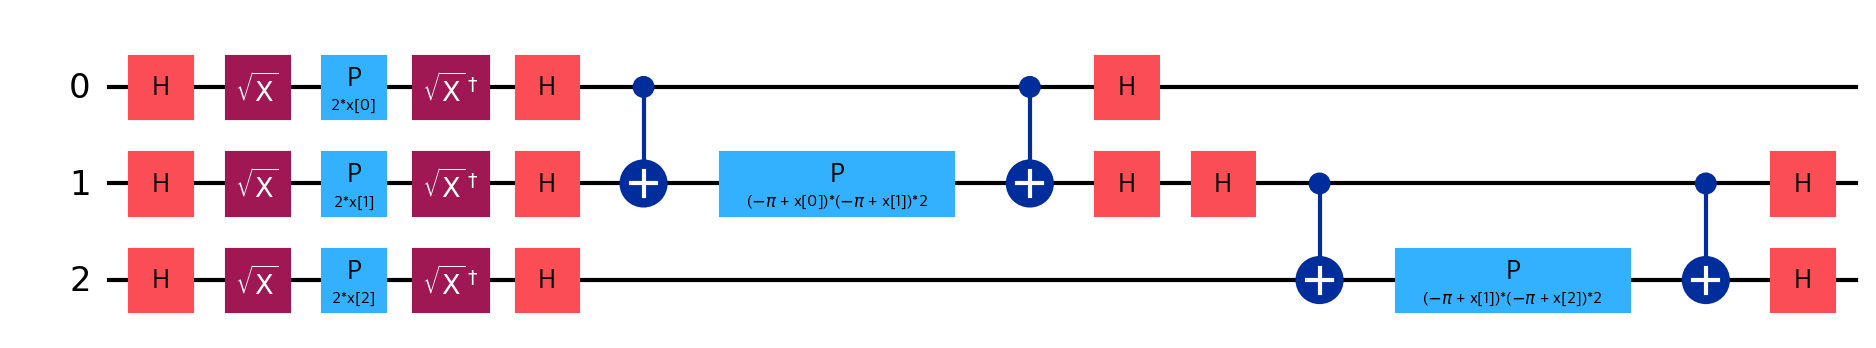

In [32]:
from qiskit.circuit.library import pauli_feature_map

# 3차원 특성, Pauli 문자열: Y (단일 큐비트) + XX (2큐비트 얽힘)
feature_dim = 3
pfmap = pauli_feature_map(
    feature_dimension=feature_dim,
    entanglement="linear",
    reps=1,
    paulis=["Y", "XX"],   # Y: 단일 큐비트 회전, XX: 2큐비트 상호작용
    alpha=2.0
)

print(f"특성 차원: {feature_dim}, Pauli 문자열: ['Y', 'XX']")
pfmap.draw("mpl", scale=1.5)



### (Optional) 9. 피처 맵의 동작 원리 시각화 — "고차원으로 올린다"는 것과 3D 투영

> **이 섹션은 Qiskit v2.X 자격증 시험 범위에 포함되지 않습니다.** 피처 맵이 데이터를 어떻게 변환하는지 직관을 얻고 싶은 분만 참고하세요.

피처 맵이 **2차원 고전 데이터를 4차원 복소 양자 상태**로 매핑하면 어떤 일이 생기는지 직접 살펴봅니다.

$$
\text{2D 고전 데이터} \quad \vec{x} = (x_1, x_2)
\quad \xrightarrow{\text{ZZ 피처 맵}} \quad
|\Phi(\vec{x})\rangle \in \mathbb{C}^4
$$

다만 $\mathbb{C}^4$ 전체를 그대로 그릴 수는 없으므로, 아래에서는 **물리적으로 의미 있는 실수 관측량**
$\langle XI \rangle$, $\langle IX \rangle$, $\langle XX \rangle$
를 사용해 3차원으로 **투영(projection)** 하겠습니다.

- $\langle XI \rangle$, $\langle IX \rangle$: 각 큐비트의 X-basis 성분
- $\langle XX \rangle$: 두 큐비트 상관관계에 민감한 항

즉, 아래 3D 그림은 **전체 양자 feature space 자체가 아니라**, 그 구조를 보여 주는 한 가지 관측량 기반 투영입니다.

> **주의:** 이 3개의 관측량은 시각화를 위해 선택한 것이며, 다른 관측량 조합(예: $\langle ZI \rangle$, $\langle ZZ \rangle$ 등)으로는 다른 분리 양상이 나타날 수 있습니다. 분류 성능 자체는 관측량 투영이 아니라 **전체 양자 커널 행렬**에 의해 결정됩니다.


In [33]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from qiskit.quantum_info import Statevector, state_fidelity, Pauli
from qiskit.circuit.library import zz_feature_map, z_feature_map
from math import pi

# === 선형 분리 불가능한 원형 데이터 생성 ===
np.random.seed(42)
n_per_class = 30

# 클래스 0: 안쪽 원
theta_inner = np.random.uniform(0, 2*pi, n_per_class)
r_inner = np.random.uniform(0, 0.6, n_per_class)
X_inner = np.column_stack([r_inner * np.cos(theta_inner), r_inner * np.sin(theta_inner)])

# 클래스 1: 바깥쪽 링
theta_outer = np.random.uniform(0, 2*pi, n_per_class)
r_outer = np.random.uniform(0.9, 1.5, n_per_class)
X_outer = np.column_stack([r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)])

X_all = np.vstack([X_inner, X_outer])
y_all = np.array([0]*n_per_class + [1]*n_per_class)

# feature map에는 보통 bounded input을 넣는 편이 해석에 유리하므로,
# 여기서는 각 축을 [0, π] 범위로 스케일링해서 사용한다.
x_min = X_all.min(axis=0)
x_max = X_all.max(axis=0)
X_all_scaled = (X_all - x_min) / (x_max - x_min) * pi
X_inner_scaled = X_all_scaled[:n_per_class]
X_outer_scaled = X_all_scaled[n_per_class:]

# 헬퍼 함수
def encode_feature_state(x, feature_map_circuit):
    bound = feature_map_circuit.assign_parameters(x)
    return Statevector.from_instruction(bound)

def quantum_kernel(X, feature_map):
    states = [encode_feature_state(x, feature_map) for x in X]
    n = len(X)
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            K[i, j] = state_fidelity(states[i], states[j])
    return K


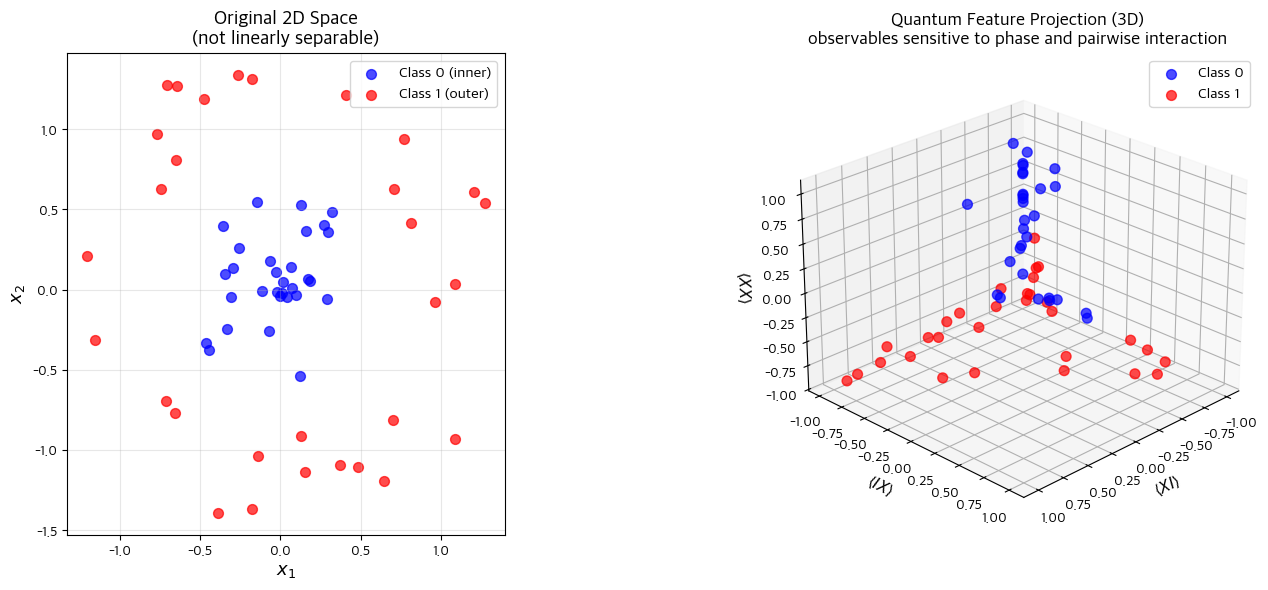

=== Quantum Kernel: Intra-class vs Inter-class Similarity ===

Feature Map            |  Intra-class |  Inter-class |      Gap
--------------------------------------------------------------
Z  (no entanglement)   |       0.5340 |       0.1192 |  +0.4147
ZZ (with interaction)  |       0.4018 |       0.1647 |  +0.2370


In [34]:


zzfm_viz = zz_feature_map(feature_dimension=2, entanglement="linear", reps=1, alpha=2.0)

# 양자 상태를 <XI>, <IX>, <XX> 관측량으로 3D 실수 공간에 투영
obs = [Pauli("XI"), Pauli("IX"), Pauli("XX")]
projection = []
for x in X_all_scaled:
    state = encode_feature_state(x, zzfm_viz)
    projection.append([np.real(state.expectation_value(pauli)) for pauli in obs])

projection = np.array(projection)

# --- 시각화 ---
fig = plt.figure(figsize=(16, 6))

# 왼쪽: 원래 2D 데이터
ax1 = fig.add_subplot(121)
ax1.scatter(X_all[y_all == 0, 0], X_all[y_all == 0, 1], c="blue", label="Class 0 (inner)", s=50, alpha=0.7)
ax1.scatter(X_all[y_all == 1, 0], X_all[y_all == 1, 1], c="red", label="Class 1 (outer)", s=50, alpha=0.7)
ax1.set_xlabel("$x_1$", fontsize=13)
ax1.set_ylabel("$x_2$", fontsize=13)
ax1.set_title("Original 2D Space\n(not linearly separable)", fontsize=14)
ax1.legend(fontsize=11)
ax1.set_aspect("equal")
ax1.grid(True, alpha=0.3)

# 오른쪽: 관측량 기반 3D 투영
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(projection[y_all == 0, 0], projection[y_all == 0, 1], projection[y_all == 0, 2],
            c="blue", label="Class 0", s=50, alpha=0.7)
ax2.scatter(projection[y_all == 1, 0], projection[y_all == 1, 1], projection[y_all == 1, 2],
            c="red", label="Class 1", s=50, alpha=0.7)
ax2.set_xlabel(r"$\langle XI \rangle$", fontsize=11)
ax2.set_ylabel(r"$\langle IX \rangle$", fontsize=11)
ax2.set_zlabel(r"$\langle XX \rangle$", fontsize=11)
ax2.set_title("Quantum Feature Projection (3D)\nobservables sensitive to phase and pairwise interaction", fontsize=13)
ax2.legend(fontsize=11)
ax2.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

# === Z vs ZZ 커널 유사도 정량 비교 ===
n_s = 12
X_s = np.vstack([X_inner_scaled[:n_s], X_outer_scaled[:n_s]])

zfm = z_feature_map(feature_dimension=2, reps=1, alpha=2.0)
zzfm_cmp = zz_feature_map(feature_dimension=2, entanglement="linear", reps=1, alpha=2.0)

K_z = quantum_kernel(X_s, zfm)
K_zz = quantum_kernel(X_s, zzfm_cmp)

print("=== Quantum Kernel: Intra-class vs Inter-class Similarity ===\n")
print(f"{'Feature Map':<22} | {'Intra-class':>12} | {'Inter-class':>12} | {'Gap':>8}")
print("-" * 62)
for name, K in [("Z  (no entanglement)", K_z), ("ZZ (with interaction)", K_zz)]:
    intra = (np.mean(K[:n_s, :n_s]) + np.mean(K[n_s:, n_s:])) / 2
    inter = np.mean(K[:n_s, n_s:])
    print(f"{name:<22} | {intra:>12.4f} | {inter:>12.4f} | {intra - inter:>+8.4f}")



해석:
- 위 수치는 이 샘플 데이터와 이 스케일링에서 계산한 결과입니다.
- Gap = intra-class 평균 유사도 - inter-class 평균 유사도 입니다.
- ZZ 피처 맵은 기본 data map에 pairwise interaction 항이 들어가므로,데이터 구조에 따라 Z 피처 맵과 다른 커널 기하를 만들 수 있습니다.



## Part 3: 변분 안사츠 (Variational Ansatz)

앞서 다룬 데이터 인코딩과 피처 맵은 고전 데이터를 양자 상태로 바꾸는 것이 목적이었습니다. 이제부터는 **학습 가능한 매개변수 회로**, 즉 변분 안사츠를 봅니다.

현재 Qiskit 2.1+에서는 **함수형 API인 `efficient_su2()` 와 `n_local()` 사용이 권장**됩니다.


### 10. Efficient SU2

#### 직관적 이해

`efficient_su2()` 는 회전 층과 얽힘 층을 **교대로 여러 번 반복**하는 대표적인 hardware-efficient ansatz입니다.

#### 핵심 구조

```text
[회전 층] → [얽힘 층] → [회전 층] → [얽힘 층] → ... → [회전 층]
```

이 노트북에서는 설명을 명확히 하기 위해
- `su2_gates = ['ry', 'rz']`
- `entanglement = 'linear'`

를 명시적으로 사용하겠습니다.

#### 2큐비트 1회 반복의 구조

`efficient_su2(num_qubits=2, su2_gates=['ry','rz'], entanglement='linear', reps=1)` 는

```text
[RY(θ0), RY(θ1)] → [RZ(θ2), RZ(θ3)] → CX(0,1) → [RY(θ4), RY(θ5)] → [RZ(θ6), RZ(θ7)]
```

형태가 됩니다. 즉, 2큐비트 1회 반복에서는
- 첫 회전 층에 4개 매개변수
- 마지막 회전 층에 4개 매개변수

가 들어가 총 8개 매개변수를 사용합니다.

#### 다른 인코딩과의 핵심 차이점

앞서 본 각도/위상/밀집 각도 인코딩은 **데이터 값이 곧 회로 매개변수**였습니다.

- 각도 인코딩: 값이 1.5이면 → `ry(1.5)` 적용
- 위상 인코딩: 값이 \(\pi/2\) 이면 → `p(\pi/2)` 적용

반면 `efficient_su2()` 는 원래 **학습해야 할 매개변수 회로**입니다. 따라서 보통 두 방식으로 쓰입니다.

| 사용 방식 | 설명 | 매개변수의 의미 |
|:---|:---|:---|
| **방식 A: 데이터 직접 대입** | 데이터 값을 슬롯에 순서대로 넣음 | 데이터 자체 |
| **방식 B: 최적화로 매개변수 탐색** | 원하는 상태/비용함수를 기준으로 최적화 | 학습해야 할 미지수 |


#### 10-1. 회로 구조 살펴보기

매개변수 수: 16


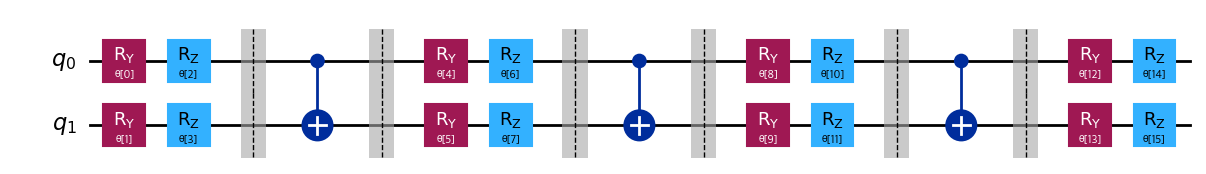

In [16]:
from qiskit.circuit.library import efficient_su2

# 2큐비트, 3회 반복 — 매개변수 수: 2큐비트 × 2게이트(Ry, Rz) × (3+1)층 = 16개
circuit = efficient_su2(
    num_qubits=2,
    su2_gates=["ry", "rz"],
    entanglement="linear",
    reps=3,
    insert_barriers=True,
)
print(f"매개변수 수: {circuit.num_parameters}")
circuit.draw(output="mpl")


큐비트 수를 늘리면 더 많은 매개변수를 인코딩할 수 있습니다. 단, 매개변수가 너무 많으면 같은 상태를 만드는 매개변수 조합이 여러 개 존재할 수 있습니다 (과매개변수화):

매개변수 수: 18


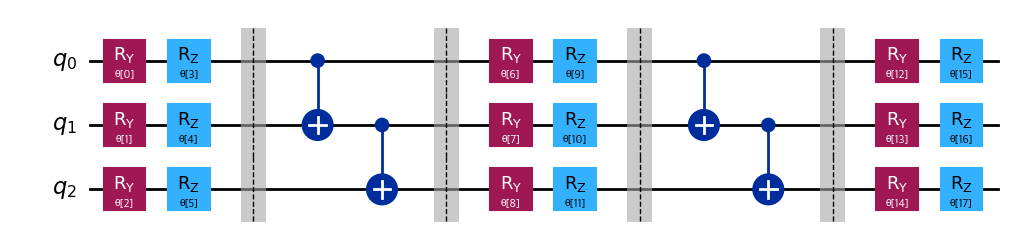

In [17]:
from qiskit.circuit.library import efficient_su2

# 3큐비트, 2회 반복
circuit = efficient_su2(
    num_qubits=3,
    su2_gates=["ry", "rz"],
    entanglement="linear",
    reps=2,
    insert_barriers=True,
)
print(f"매개변수 수: {circuit.num_parameters}")
circuit.draw(output="mpl")


#### 10-2. 방식 A — 데이터 직접 대입

가장 단순한 사용법은 데이터 값을 매개변수에 **직접 대입**하는 것입니다. 매개변수 슬롯의 수와 데이터 차원이 일치해야 합니다.

> **주의:** 아래 코드에서 `[0.1, 0.2, ..., 1.2]` 같은 값은 **임의로 선택한 예시**입니다. 각도/위상 인코딩처럼 "값 → 게이트"의 직관적 대응이 있는 것이 아니라, 데이터를 매개변수 순서대로 채워 넣는 것뿐입니다. 따라서 이 방식은 간단하지만, 인코딩의 의미가 불명확할 수 있습니다.

필요 매개변수 수: 12, 제공된 데이터 수: 12


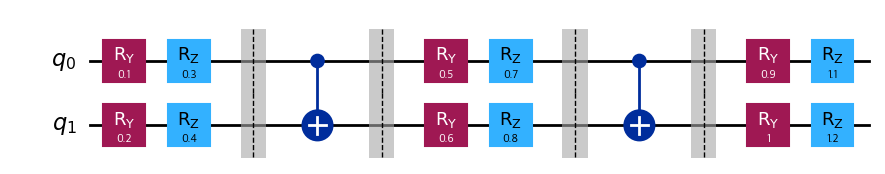

In [18]:
from qiskit.circuit.library import efficient_su2

# 데이터 포인트 (12개의 특성값)
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]

# 회로 생성 후 매개변수 할당
circuit = efficient_su2(
    num_qubits=2,
    su2_gates=["ry", "rz"],
    entanglement="linear",
    reps=2,
    insert_barriers=True,
)
encode = circuit.assign_parameters(x)

print(f"필요 매개변수 수: {circuit.num_parameters}, 제공된 데이터 수: {len(x)}")
encode.draw(output="mpl")


3큐비트 예제:

필요 매개변수 수: 12, 제공된 데이터 수: 12


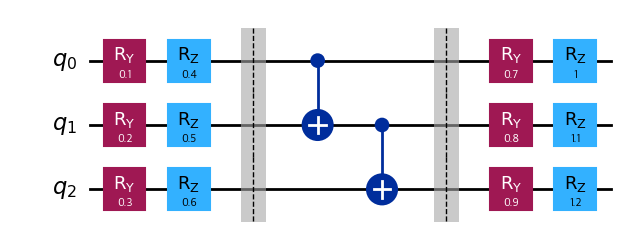

In [19]:
from qiskit.circuit.library import efficient_su2

x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
circuit = efficient_su2(
    num_qubits=3,
    su2_gates=["ry", "rz"],
    entanglement="linear",
    reps=1,
    insert_barriers=True,
)
encode = circuit.assign_parameters(x)

print(f"필요 매개변수 수: {circuit.num_parameters}, 제공된 데이터 수: {len(x)}")
encode.draw(output="mpl")


#### 10-3. ( Optional) 방식 B — 최적화로 원하는 상태 만들기 (변분 접근)

> **이 섹션은 Qiskit v2.X 자격증 시험 범위에 포함되지 않습니다.** 시험에서는 `efficient_su2()` 회로 생성과 `assign_parameters()` 사용법이 핵심입니다.

Efficient SU2의 **가장 대표적인 활용법**은 원하는 목표 상태(target state)를 만들기 위해 **최적화 알고리즘**으로 최적의 매개변수를 찾는 것입니다. 이것이 VQE, 변분 양자 분류기 등 변분 알고리즘의 핵심 원리입니다.

##### 작동 원리

1. **목표 상태 정의:** 만들고 싶은 양자 상태를 정합니다 (예: Bell 상태)
2. **비용 함수 정의:** 현재 매개변수로 만든 상태와 목표 상태의 "거리"를 계산합니다
3. **최적화:** scipy 같은 최적화 라이브러리로 비용 함수를 최소화하는 매개변수를 찾습니다
4. **결과 확인:** 찾은 매개변수를 회로에 넣어 목표 상태가 잘 재현되는지 확인합니다

아래 예제에서는 **Bell 상태** $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$를 Efficient SU2 회로로 만들어 봅니다. Bell 상태는 양자 얽힘의 대표적인 예로, 두 큐비트가 완벽하게 상관된 상태입니다.

In [36]:

import numpy as np
from scipy.optimize import minimize
from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import Statevector, state_fidelity

# ===== 1단계: 목표 상태 정의 =====
# Bell 상태: (1/√2)(|00⟩ + |11⟩)
target_state = Statevector([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])
print("목표 상태 (Bell 상태):")
print(f"  |00⟩ 진폭: {target_state[0]:.4f}")
print(f"  |01⟩ 진폭: {target_state[1]:.4f}")
print(f"  |10⟩ 진폭: {target_state[2]:.4f}")
print(f"  |11⟩ 진폭: {target_state[3]:.4f}")

# ===== 2단계: efficient_su2 회로 준비 =====
ansatz = efficient_su2(
    num_qubits=2,
    su2_gates=["ry", "rz"],
    entanglement="linear",
    reps=1,
    insert_barriers=True,
)
print(f"\n회로 매개변수 수: {ansatz.num_parameters}")

# ===== 3단계: 비용 함수 정의 =====
# Fidelity(충실도): 두 양자 상태가 얼마나 가까운지 0~1로 나타냄
# 1이면 완벽히 일치, 0이면 완전히 다름
# 비용 = 1 - Fidelity (최소화 목표)
def cost_function(params):
    circuit = ansatz.assign_parameters(params)
    current_state = Statevector.from_instruction(circuit)
    fidelity = state_fidelity(current_state, target_state)
    return 1 - fidelity  # 충실도가 높을수록 비용이 낮음

# ===== 4단계: 최적화 실행 =====
# 초기 매개변수: 무작위 값에서 시작
np.random.seed(42)  # 재현성을 위한 시드 고정
initial_params = np.random.uniform(0, 2*np.pi, ansatz.num_parameters)

print(f"\n최적화 시작...")
print(f"초기 비용 (1-Fidelity): {cost_function(initial_params):.6f}")

result = minimize(
    cost_function,
    initial_params,
    method="COBYLA",     # 그래디언트 불필요한 최적화 알고리즘
    options={"maxiter": 1000}
)

print(f"최적화 완료!")
print(f"최종 비용 (1-Fidelity): {result.fun:.6f}")
print(f"최종 충실도 (Fidelity): {1 - result.fun:.6f}")
print(f"반복 횟수: {result.nfev}")


목표 상태 (Bell 상태):
  |00⟩ 진폭: 0.7071+0.0000j
  |01⟩ 진폭: 0.0000+0.0000j
  |10⟩ 진폭: 0.0000+0.0000j
  |11⟩ 진폭: 0.7071+0.0000j

회로 매개변수 수: 8

최적화 시작...
초기 비용 (1-Fidelity): 0.638024
최적화 완료!
최종 비용 (1-Fidelity): 0.000000
최종 충실도 (Fidelity): 1.000000
반복 횟수: 137


최적화된 회로:


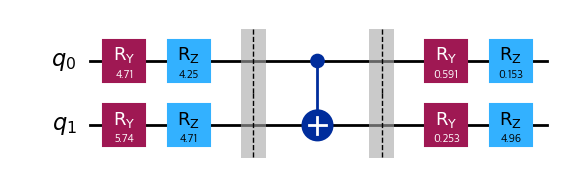


상태 비교:
  목표 상태  |00⟩: 0.7071+0.0000j,  |01⟩: 0.0000+0.0000j,  |10⟩: 0.0000+0.0000j,  |11⟩: 0.7071+0.0000j
  최적 상태  |00⟩: 0.7071,  |01⟩: 0.0001,  |10⟩: 0.0001,  |11⟩: 0.7071

충실도: 1.000000 (1.0에 가까울수록 좋음)


In [37]:

# ===== 5단계: 결과 확인 및 시각화 =====
from qiskit.visualization import plot_bloch_multivector

# 최적화된 매개변수로 회로 구성
optimal_circuit = ansatz.assign_parameters(result.x)

print("최적화된 회로:")
display(optimal_circuit.draw("mpl"))

# 최적화된 상태와 목표 상태 비교
optimal_state = Statevector.from_instruction(optimal_circuit)

print("\n상태 비교:")
print(f"  목표 상태  |00⟩: {target_state[0]:.4f},  |01⟩: {target_state[1]:.4f},  |10⟩: {target_state[2]:.4f},  |11⟩: {target_state[3]:.4f}")
print(f"  최적 상태  |00⟩: {abs(optimal_state[0]):.4f},  |01⟩: {abs(optimal_state[1]):.4f},  |10⟩: {abs(optimal_state[2]):.4f},  |11⟩: {abs(optimal_state[3]):.4f}")
print(f"\n충실도: {state_fidelity(optimal_state, target_state):.6f} (1.0에 가까울수록 좋음)")

위 코드의 결과에서 확인할 수 있는 점:

- **충실도(Fidelity)가 1.0에 가까움:** 최적화가 성공적으로 목표 상태(Bell 상태)를 찾았다는 뜻입니다
- **Bloch 구면에서 원점 근처:** Bell 상태는 최대 얽힘 상태이므로, 개별 큐비트의 축소 밀도 행렬은 완전 혼합 상태(Bloch 구면의 원점)가 됩니다. 이것은 오류가 아니라 얽힘의 자연스러운 결과입니다

이것이 바로 **변분 양자 알고리즘**의 핵심 원리입니다:
1. 매개변수화된 회로(ansatz)를 정의하고
2. 비용 함수를 설계한 다음
3. 고전 최적화로 최적 매개변수를 찾습니다

### 2-local 구조 (최신 권장 API: `n_local`)

문헌과 예전 코드에서는 `TwoLocal` 이라는 클래스를 많이 보게 됩니다. 하지만 **현재 Qiskit에서는 `TwoLocal` 클래스가 deprecated**이고, 같은 개념을 **`n_local()` 함수로 구현하는 방식**이 권장됩니다.

개념적으로 TwoLocal은
- **회전 층:** 지정한 단일 큐비트 게이트들
- **얽힘 층:** 지정한 2큐비트 게이트들
- **반복 수(`reps`)** 로 깊이 조절

이라는 구조를 가집니다.

아래 코드는 예전 `TwoLocal(5, ['ry','rz'], 'cx', 'linear', reps=1)` 와 같은 아이디어를 **최신 함수형 API**로 작성한 예제입니다.


매개변수 수: 20


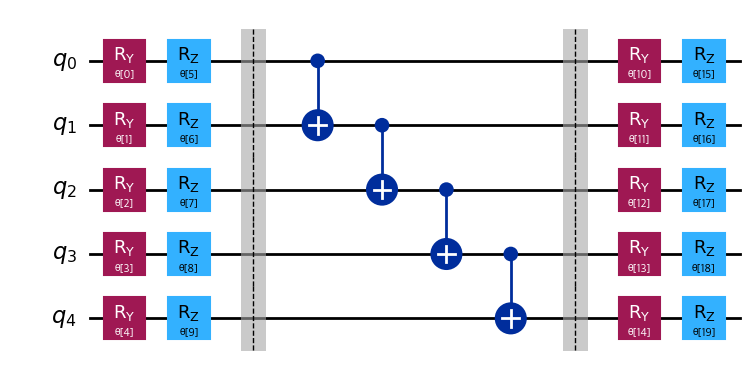

In [23]:
from qiskit.circuit.library import n_local

# 5큐비트, Ry+Rz 회전, CX 얽힘, 선형 연결, 1회 반복
two_local_like = n_local(
    num_qubits=5,
    rotation_blocks=["ry", "rz"],     # 각 큐비트에 Ry -> Rz 적용
    entanglement_blocks="cx",         # CNOT으로 인접 큐비트 연결
    entanglement="linear",            # 선형 연결: 0-1, 1-2, 2-3, 3-4
    reps=1,
    insert_barriers=True
)
print(f"매개변수 수: {two_local_like.num_parameters}")
two_local_like.draw("mpl")


### 12. NLocal 계열의 일반화 (최신 권장 API: `n_local`)

`NLocal` 은 더 일반적인 n-local ansatz 개념입니다. 과거에는 `NLocal` 클래스와 그 하위 클래스들(`TwoLocal`, `EfficientSU2`, `RealAmplitudes` 등)을 많이 사용했지만, **현재 Qiskit에서는 이 계열 전체에 대해 함수형 API가 권장**됩니다.

핵심 아이디어는 같습니다.

- 회전 블록은 꼭 1큐비트 게이트일 필요가 없음
- 얽힘 블록도 꼭 2큐비트 gate 하나일 필요가 없음
- 따라서 더 다양한 구조를 유연하게 만들 수 있음

아래 예제는 `n_local()` 로 좀 더 일반적인 ansatz를 만드는 예입니다.


매개변수 수: 34


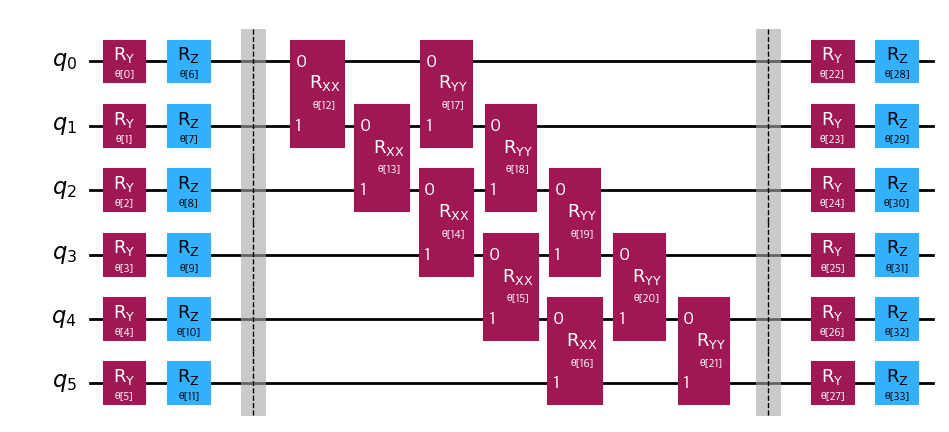

In [24]:
from qiskit.circuit.library import n_local

# 6큐비트, Ry+Rz 회전, RXX+RYY 상호작용
nlocal = n_local(
    num_qubits=6,
    rotation_blocks=["ry", "rz"],        # 단일 큐비트 회전
    entanglement_blocks=["rxx", "ryy"],  # 2큐비트 상호작용 (XX, YY 회전)
    entanglement="linear",
    reps=1,
    insert_barriers=True
)
print(f"매개변수 수: {nlocal.num_parameters}")
nlocal.draw("mpl")


## 연습 문제

**1. 기저 인코딩에서 값 5 (이진수 0101)가 있는 데이터셋을 양자 상태로 어떻게 인코딩하나요?**

A) 진폭으로: $\sqrt{5} |0\rangle$

B) 계산 기저 상태로: $|0101\rangle$

C) 회전 각도로: $R_y(5)|0\rangle$

D) 위상으로: $e^{i5}|+\rangle$

***정답:***
<Details>
<br/>

B) 계산 기저 상태로: $|0101\rangle$

기저 인코딩에서는 각 특성값을 이진수로 변환한 뒤, 해당 비트 문자열을 큐비트의 계산 기저 상태로 직접 매핑합니다. 

A) → 진폭 인코딩이 이런 형태지만, 정규화가 빠져있어서 틀린 표현
C) → 각도 인코딩의 형태이며, 실전에서는 스케일링이 필요함
D) → 위상 인코딩의 형태이며, H→P 과정과 스케일이 필요함
</Details>

**2. 연속형 특성값을 각 큐비트의 회전각으로 직접 넣는 인코딩 방식은 무엇인가요?**

A) 위상 인코딩 (Phase Encoding)

B) 진폭 인코딩 (Amplitude Encoding)

C) 각도 인코딩 (Angle Encoding)

D) Efficient SU2 인코딩

***정답:***
<Details>
<br/>
C) 각도 인코딩 (Angle Encoding)

각도 인코딩은 각 특성값을 해당 큐비트의 회전각으로 직접 매핑합니다.

A) 위상 인코딩 — 하다마드 후 위상 게이트를 사용하는 방식

B) 진폭 인코딩 — 벡터 전체를 정규화하여 진폭에 저장하는 방식

D) Efficient SU2 — 인코딩이 아니라 학습 가능한 변분 안사츠
</Details>


**3. 진폭 인코딩은 입력 벡터의 정규화가 필요합니다. 입력 벡터가 (5, 7, 1)일 때 정규화 상수는 무엇인가요?**

A) $\sqrt{12}$

B) 75

C) $\sqrt{75}$

D) 12

***정답:***
<Details>
<br/>

C) $\sqrt{75}$

$\|\vec{x}\|^2 = 5^2 + 7^2 + 1^2 = 25 + 49 + 1 = 75$이므로, 정규화 상수는 $\sqrt{75} = 5\sqrt{3}$입니다.
양자 상태의 확률 총합이 1이 되려면 모든 진폭을 이 상수로 나눠야 합니다.
</Details>